# 05 — LiDAR BEV detection and temporal tracking

*The full dataset remains outside Git. These notebooks combine synthetic worked examples, aggregate evidence, and small attributed qualitative panels.*

In [1]:
from pathlib import Path
import json
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

ROOT = Path.cwd()
sys.path.insert(0, str(ROOT / "src"))
plt.style.use("seaborn-v0_8-whitegrid")
summary = json.loads((ROOT / "reports" / "benchmark_summary.json").read_text())

## Learning objective and system boundary

This track asks **what occupies the metric space around the ego vehicle?** It
turns calibrated LiDAR and front-camera evidence into oriented bird's-eye-view
(BEV) objects. It does not choose a route, forecast another driver's intent, or
control steering and braking.

```text
raw LiDAR → motion compensation → LiDAR-to-ego SE(3) → 3-channel BEV
          → SFA3D center detector → metric oriented boxes → Kalman tracks
```

The final experiment moves beyond the original 12-frame transfer diagnostic.
It uses protected 70/16/30 recording roles, staged ZOD fine-tuning, native
PointPillars and CenterPoint controls, single-versus-five-sweep selection, and
calibrated camera-LiDAR fusion. External source and weights remain outside Git.

## Coordinate frames and calibration

ZOD ego coordinates are right-handed: (x) forward, (y) left, (z) up.
Raw LiDAR points are first motion-compensated to the keyframe time and then
transformed with the calibrated homogeneous pose

\[
\tilde{\mathbf p}_{ego}=T^{ego}_{lidar}\tilde{\mathbf p}_{lidar},
\qquad \tilde{\mathbf p}=[x,y,z,1]^\top.
\]

The BEV covers (x\in[0,50]) m, (y\in[-25,25]) m, and
(z\in[-1,3]) m. Raster row increases forward; column increases left. The
renderer rotates the array so forward appears at the top while preserving the
metric convention in every model and evaluation calculation.

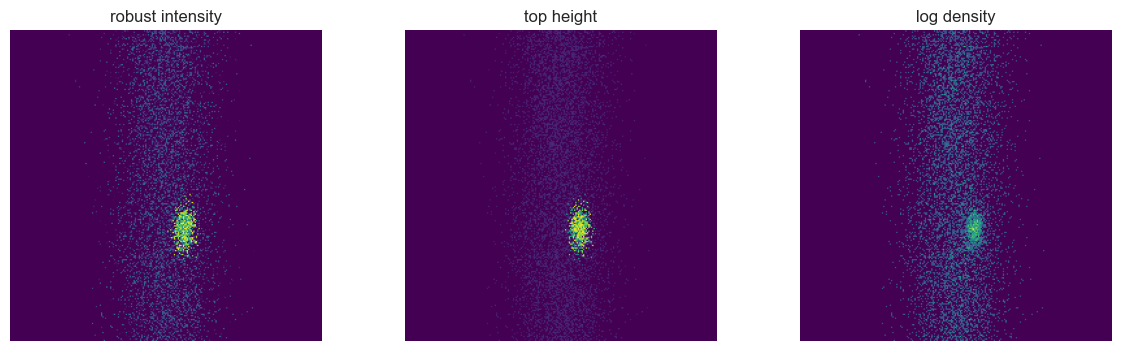

In [2]:
from zod_driveformer.bev import BEVConfig, build_bev_layers

rng=np.random.default_rng(7)
road=np.column_stack((rng.uniform(0,50,7000), rng.normal(0,4,7000), rng.normal(-.8,.04,7000)))
car=np.column_stack((rng.normal(18,1.8,900), rng.normal(-3,0.8,900), rng.uniform(-.6,1.2,900)))
points=np.vstack((road,car)).astype('float32')
intensity=np.r_[rng.uniform(20,90,len(road)),rng.uniform(90,220,len(car))]
demo_cfg=BEVConfig(height=240,width=240)
demo_layers=build_bev_layers(points,intensity,demo_cfg)
fig,ax=plt.subplots(1,3,figsize=(12,3.6))
for axis,layer,title in zip(ax,[demo_layers.intensity,demo_layers.height,demo_layers.density],
                            ['robust intensity','top height','log density']):
    axis.imshow(np.rot90(layer,2),cmap='viridis'); axis.set_title(title); axis.axis('off')
plt.tight_layout(); plt.show()

## Rasterization math

For cell resolution (H\times W), a point is quantized as

\[
r=\left\lfloor H\frac{x-x_{min}}{x_{max}-x_{min}}\right\rfloor,
\quad
c=\left\lfloor W\frac{y-y_{min}}{y_{max}-y_{min}}\right\rfloor.
\]

Within each cell the highest return supplies normalized height
(h=(z-z_{min})/(z_{max}-z_{min})) and robustly percentile-scaled intensity.
All returns contribute to density

\[
d=\min\left(1,\frac{\log(1+n)}{\log 64}\right).
\]

This compresses an unordered point set into three translation-aligned image
channels. It is fast and CNN-friendly, but vertical detail and multiple surfaces
inside one cell are deliberately discarded.

## SFA3D architecture: center-based oriented boxes

SFA3D uses an FPN-ResNet-18 backbone and several dense heads on a downsampled
BEV feature map:

| Head | Meaning | Decoded output |
|---|---|---|
| `hm_cen` | per-class center heatmap | class and confidence |
| `cen_offset` | sub-cell center correction | continuous (x,y) |
| `direction` | sine/cosine-like orientation pair | yaw (psi) |
| `dim` | object dimensions | length and width |
| `z_coor` | vertical center | retained by SFA3D, outside 2-D metric here |

The heatmap formulation avoids proposing thousands of anchors. Local maxima are
confidence-ranked and mapped from pixels back into ZOD ego metres. The operating
threshold is selected on validation; AP ranks confidences rather than depending
on one attractive test threshold.

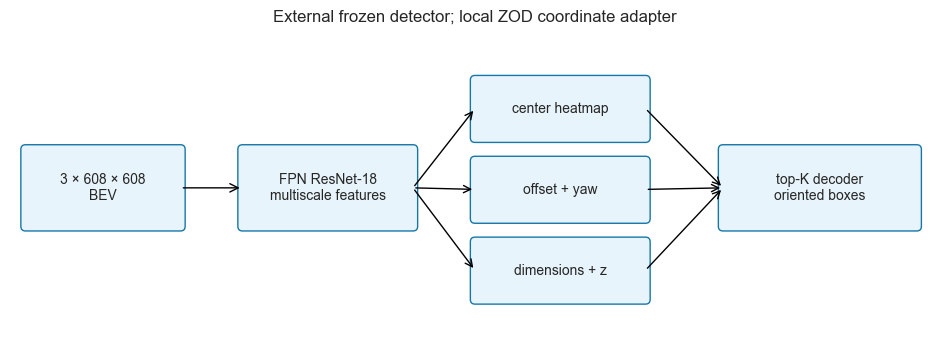

In [3]:
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
fig,ax=plt.subplots(figsize=(12,4)); ax.set_xlim(0,12); ax.set_ylim(0,4); ax.axis('off')
nodes=[(.2,1.45,2.0,1.0,'3 × 608 × 608\nBEV'),(3.0,1.45,2.2,1.0,'FPN ResNet-18\nmultiscale features'),
       (6.0,2.6,2.2,.75,'center heatmap'),(6.0,1.55,2.2,.75,'offset + yaw'),
       (6.0,.5,2.2,.75,'dimensions + z'),(9.2,1.45,2.5,1.0,'top-K decoder\noriented boxes')]
for x,y,w,h,label in nodes:
    ax.add_patch(FancyBboxPatch((x,y),w,h,boxstyle='round,pad=.06',fc='#e8f4fb',ec='#1677a7'))
    ax.text(x+w/2,y+h/2,label,ha='center',va='center')
ax.add_patch(FancyArrowPatch((2.2,1.95),(3,1.95),arrowstyle='->',mutation_scale=15))
for y in (2.98,1.93,.88):
    ax.add_patch(FancyArrowPatch((5.2,1.95),(6,y),arrowstyle='->',mutation_scale=13))
    ax.add_patch(FancyArrowPatch((8.2,y),(9.2,1.95),arrowstyle='->',mutation_scale=13))
ax.set_title('External frozen detector; local ZOD coordinate adapter'); plt.show()

## Target encoding, loss, and staged transfer learning

Each object center creates a class-specific Gaussian target. A CenterNet-style
objective uses focal loss for that dense heatmap and masked regression only at
true centers for offset, direction, height, and dimensions:

\[
\mathcal L=\mathcal L_{focal}(\hat H,H)
+\lambda_o\|\hat o-o\|_1
+\lambda_d\|\hat d-d\|_1
+\lambda_\psi\|\hat q-q\|_1
+\lambda_z\|\hat z-z\|_1.
\]

The center mask is essential: implementation selects valid regression values
*before* Smooth-L1 reduction, avoiding undefined `inf * 0`. Training starts from
the pinned KITTI checkpoint. Stage 1 learns heads, stage 2 unfreezes the FPN and
deep backbone, and stage 3 fine-tunes the complete network. Class-balanced
sampling raises rare-user exposure; early stopping uses validation only.

## Native 3-D controls: PointPillars and CenterPoint

The native baselines learn directly from points instead of inheriting the KITTI
BEV feature extractor. A pillar groups points in one vertical column and embeds
point coordinates, offsets from the pillar mean, and offsets from its center:

\[
f_P=\max_{i\in P}\phi([p_i,p_i-\bar p_P,p_i-c_P]).
\]

The max-pooled pillar features form a sparse pseudo-image. PointPillars uses
anchor classification and box residuals. The CenterPoint control uses the same
pillar idea with anchor-free Gaussian centers and box heads. Both were trained
from scratch on the same protected roles. Their poor sealed-test results are an
important control: 70 recordings are insufficient to learn robust 3-D features
and rare classes without transfer. This does not mean the full architecture
families are intrinsically weak.

## Multiple sweeps: more evidence can be worse

For point \(p_i\) captured at time \(t_i\), ego motion maps it to the keyframe:

\[
p_i^{e_0}=(T^w_{e_0})^{-1}T^w_{e_i}T^{e_i}_{L}p_i^L.
\]

This aligns the static world. It cannot align a pedestrian or vehicle that moves
independently between scans, so five sweeps leave object trails. Validation
macro-F1 was 0.154 for one sweep and 0.117 for five. The detector therefore uses
one sweep; the camera foreground-depth estimator uses five because robust depth
benefits from denser in-box returns.

## Camera depth lifting and class-gated fusion

Faster R-CNN supplies image-space semantic boxes. ZOD's calibrated
Kannala-Brandt camera projects a ray using

\[
r(\theta)=\theta+k_1\theta^3+k_2\theta^5+k_3\theta^7+k_4\theta^9.
\]

LiDAR points projected into the lower/central foreground of a camera box provide
a robust depth. The ray and depth lift that box into ego coordinates. Same-class
metric proposals are associated. Camera-only Pedestrian and Cyclist proposals
may supplement LiDAR, but Vehicle predictions and confidences pass through
unchanged. This explicit gate guarantees that a weaker camera vehicle estimate
cannot reduce LiDAR vehicle AP.

## Oriented intersection-over-union

Axis-aligned IoU would reward a box with the wrong heading. I construct each
footprint by rotating local corners with

\[
R(\psi)=\begin{bmatrix}\cos\psi&-\sin\psi\\\sin\psi&\cos\psi\end{bmatrix},
\]

clip the two convex polygons, and report

\[
IoU_{BEV}=\frac{|P\cap G|}{|P|+|G|-|P\cap G|}.
\]

Predictions and labels are matched one-to-one and class consistently. A
confidence-ranked precision-recall curve yields 101-point interpolated AP at
IoU 0.30, 0.50, and 0.70. The evaluator also reports center, yaw, length, and
width errors; near/mid/far range slices; expected calibration error; and Brier
score. Validation selects fixed operating thresholds separately from AP.

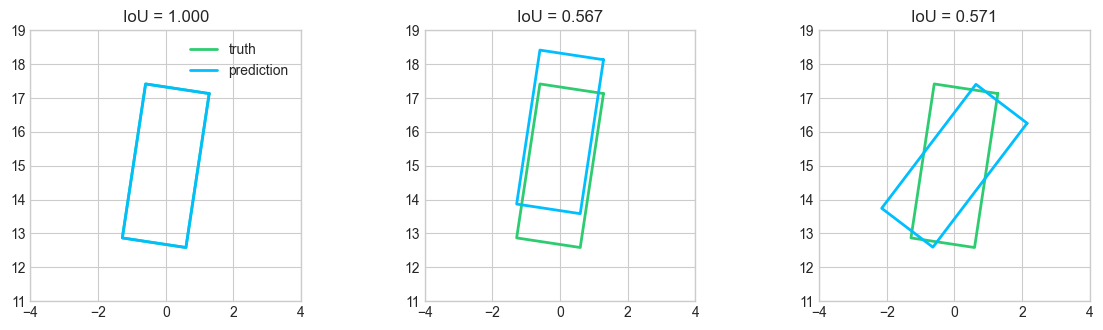

In [4]:
from zod_driveformer.bev import BEVDetection, oriented_bev_iou
from zod_driveformer.bev.evaluation import _corners
truth=BEVDetection('Vehicle',15,0,4.6,1.9,.15)
candidates=[BEVDetection('Vehicle',15+e,0,4.6,1.9,.15+a) for e,a in [(0,0),(1,0),(0,.5)]]
fig,axes=plt.subplots(1,3,figsize=(12,3.4))
for ax,pred in zip(axes,candidates):
    for box,color,label in [(truth,'#2ecc71','truth'),(pred,'#00bfff','prediction')]:
        corners=_corners(box); closed=np.vstack((corners,corners[0])); ax.plot(closed[:,1],closed[:,0],color=color,lw=2,label=label)
    ax.set_aspect('equal'); ax.set_xlim(-4,4); ax.set_ylim(11,19); ax.set_title(f'IoU = {oriented_bev_iou(pred,truth):.3f}')
axes[0].legend(); plt.tight_layout(); plt.show()

## Tracking: state, prediction, update

Each class-aware track uses state (mathbf s=[x,y,v_x,v_y]^\top). For elapsed
time (Delta t), constant-velocity prediction is

\[
\mathbf s^-_k=F\mathbf s_{k-1},\quad
P^-_k=FP_{k-1}F^\top+Q,
\quad
F=\begin{bmatrix}1&0&\Delta t&0\\0&1&0&\Delta t\\0&0&1&0\\0&0&0&1\end{bmatrix}.
\]

For measured center (mathbf z=[x,y]^\top), the Kalman update is

\[
K=P^-H^\top(HP^-H^\top+R)^{-1},\quad
\mathbf s=\mathbf s^-+K(\mathbf z-H\mathbf s^-).
\]

Class-consistent nearest-neighbor association is gated at 4 m. A track needs two
hits before display and is deleted after two misses in the animation. This is a
transparent teaching tracker, not a claim of state-of-the-art MOT accuracy.

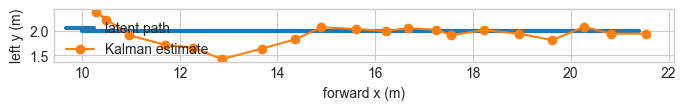

In [5]:
from zod_driveformer.bev import MultiObjectTracker
tracker=MultiObjectTracker(minimum_hits=1,maximum_misses=2)
track_xy=[]
for t in np.arange(0,4,.2):
    noisy=BEVDetection('Vehicle',10+3*t+rng.normal(0,.25),2+rng.normal(0,.25),4.5,1.9,0,0.8)
    estimate=tracker.step([noisy],dt=.2)[0]; track_xy.append((estimate.x_m,estimate.y_m,estimate.velocity_x_mps))
track_xy=np.asarray(track_xy)
fig,ax=plt.subplots(figsize=(8,3.5)); ax.plot(10+3*np.arange(0,4,.2),np.full(20,2),label='latent path',lw=3)
ax.plot(track_xy[:,0],track_xy[:,1],'o-',label='Kalman estimate'); ax.set_aspect('equal'); ax.set_xlabel('forward x (m)'); ax.set_ylabel('left y (m)'); ax.legend(); plt.show()

## Protected evaluation contract

- Data: 70 train, 16 validation, and 30 sealed test ZOD Sequences recordings.
- Targets: non-unclear Vehicle, Pedestrian, and VulnerableVehicle 3-D boxes,
  converted into ego-frame Vehicle, Pedestrian, and Cyclist footprints.
- Scope: target centers inside the 50 m × 50 m front raster.
- Models: staged ZOD-fine-tuned SFA3D, native PointPillars/CenterPoint controls,
  and calibrated camera-LiDAR fusion.
- Sweep count, checkpoints, and confidence thresholds use validation only.
- Roles are recording-disjoint, exclude mini, and are bound by private ID hashes.

Only 120 locally available recordings had complete required sensors. The cohort
supports a bounded comparison, not a production-scale or full-Frames claim.

In [6]:
bev_report=json.loads((ROOT/'reports/bev_v2_summary.json').read_text())
roles=pd.DataFrame(bev_report['dataset']['roles']).T
roles[['recordings','vehicle_instances','pedestrian_instances','cyclist_instances']]

,recordings,vehicle_instances,pedestrian_instances,cyclist_instances
test,30,351,31,18
train,70,852,50,28
validation,16,220,53,24


In [7]:
names={'sfa3d_unmodified':'Unmodified transfer',
       'sfa3d_single_sweep':'Fine-tuned SFA3D',
       'hybrid_fusion':'Hybrid fusion',
       'pointpillars_from_scratch':'PointPillars',
       'centerpoint_from_scratch':'CenterPoint'}
rows=[]
for key,label in names.items():
    values=bev_report['models'][key]
    rows.append([label,*[values[c]['iou_0.30']['ap'] for c in ['Vehicle','Pedestrian','Cyclist']]])
ap_table=pd.DataFrame(rows,columns=['model','Vehicle','Pedestrian','Cyclist']).set_index('model')
ap_table.round(3)

,Vehicle,Pedestrian,Cyclist
model,,,
Unmodified transfer,0.361,0.366,0.007
Fine-tuned SFA3D,0.616,0.501,0.156
Hybrid fusion,0.616,0.529,0.327
PointPillars,0.018,0.000,0.000
CenterPoint,0.000,0.000,0.000


## Reading the result honestly

Fine-tuning raises AP@0.30 from 0.361/0.366/0.007 to
0.616/0.501/0.156 for Vehicle/Pedestrian/Cyclist. Fusion preserves Vehicle at
0.616 by construction and raises Pedestrian to 0.529 and Cyclist to 0.327.

The native from-scratch controls fail, and five-sweep detector input loses to
one sweep. Transfer matters in this small-data regime, and ego-motion-compensated
accumulation is not object-motion compensation. The bounded test still contains
few vulnerable users, so it motivates a larger confirmation, not a safety claim.

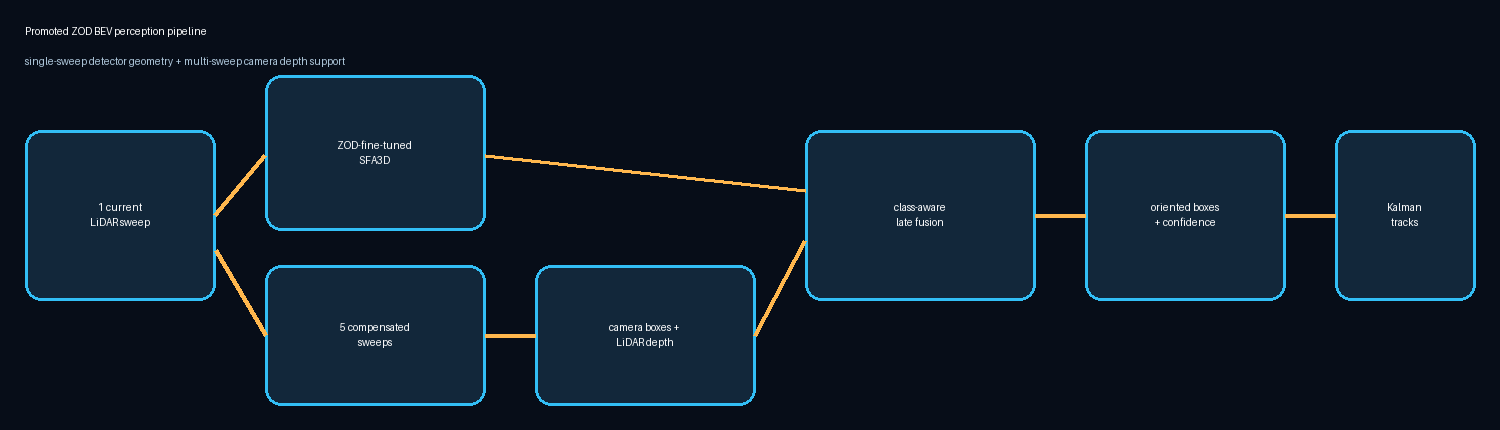

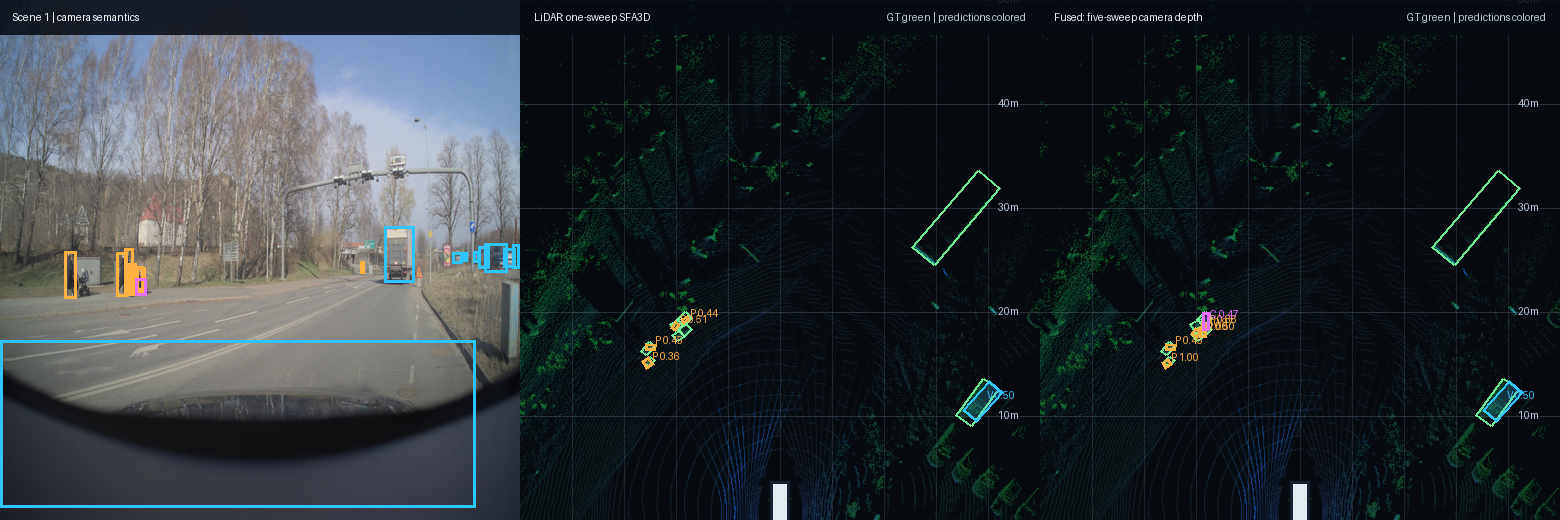

In [8]:
from IPython.display import Image as NotebookImage, display
display(NotebookImage(filename=str(ROOT/'reports/figures/bev_v2_pipeline.png')))
display(NotebookImage(filename=str(ROOT/'reports/figures/bev_v2_fusion_comparison.png')))

The camera panel explains semantic recognition; the BEV panels compare
LiDAR-only and fused metric predictions against green ground truth. Qualitative
examples aid interpretation; all sealed detections determine promotion.

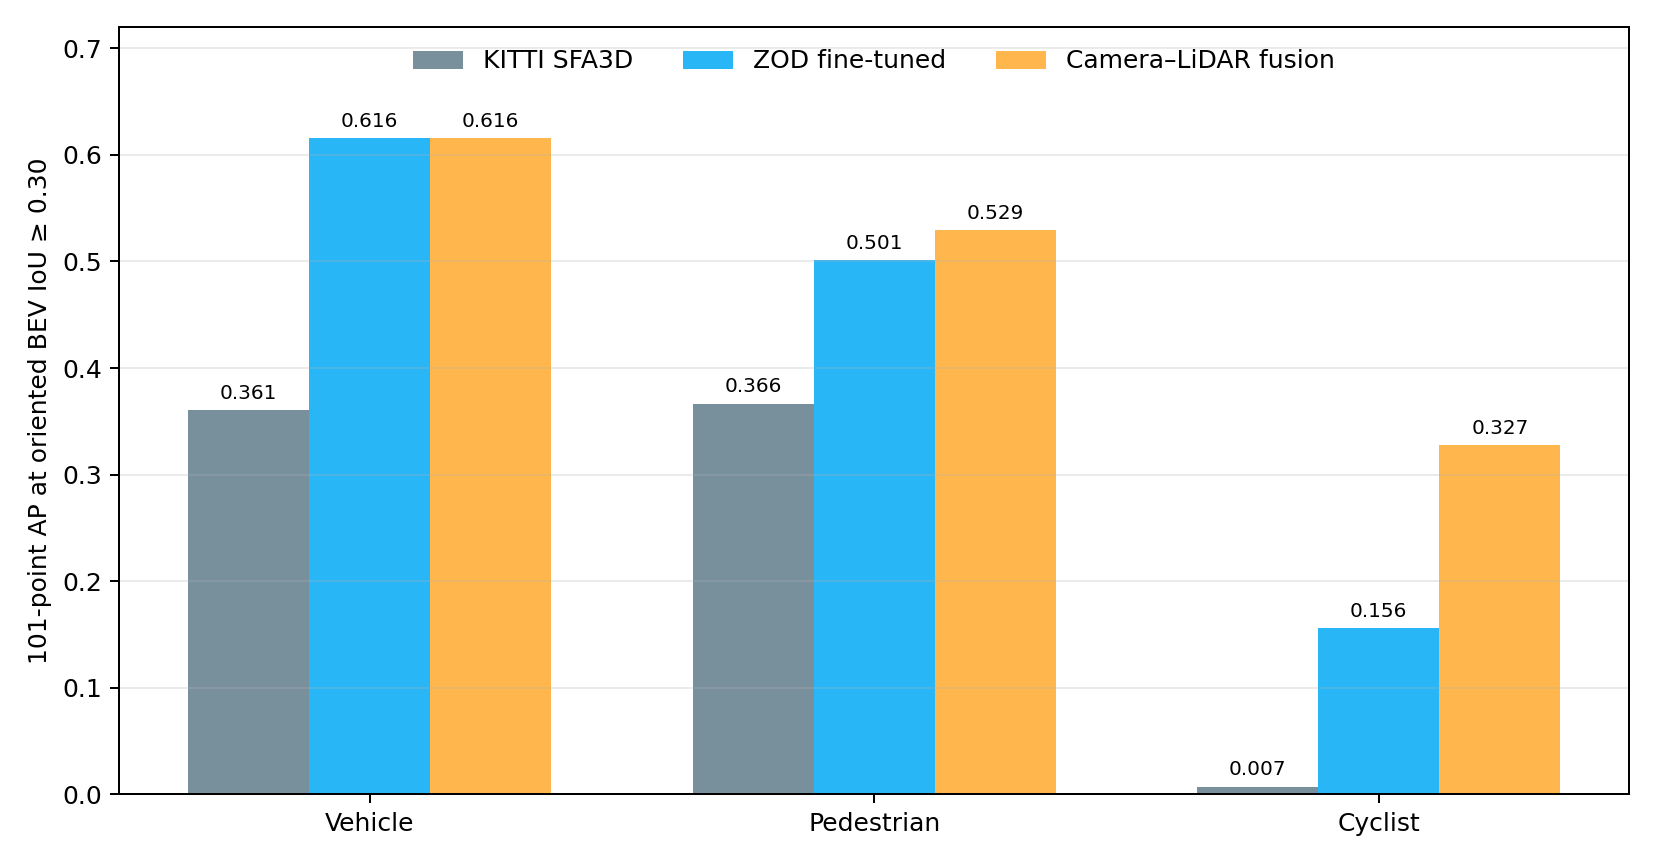

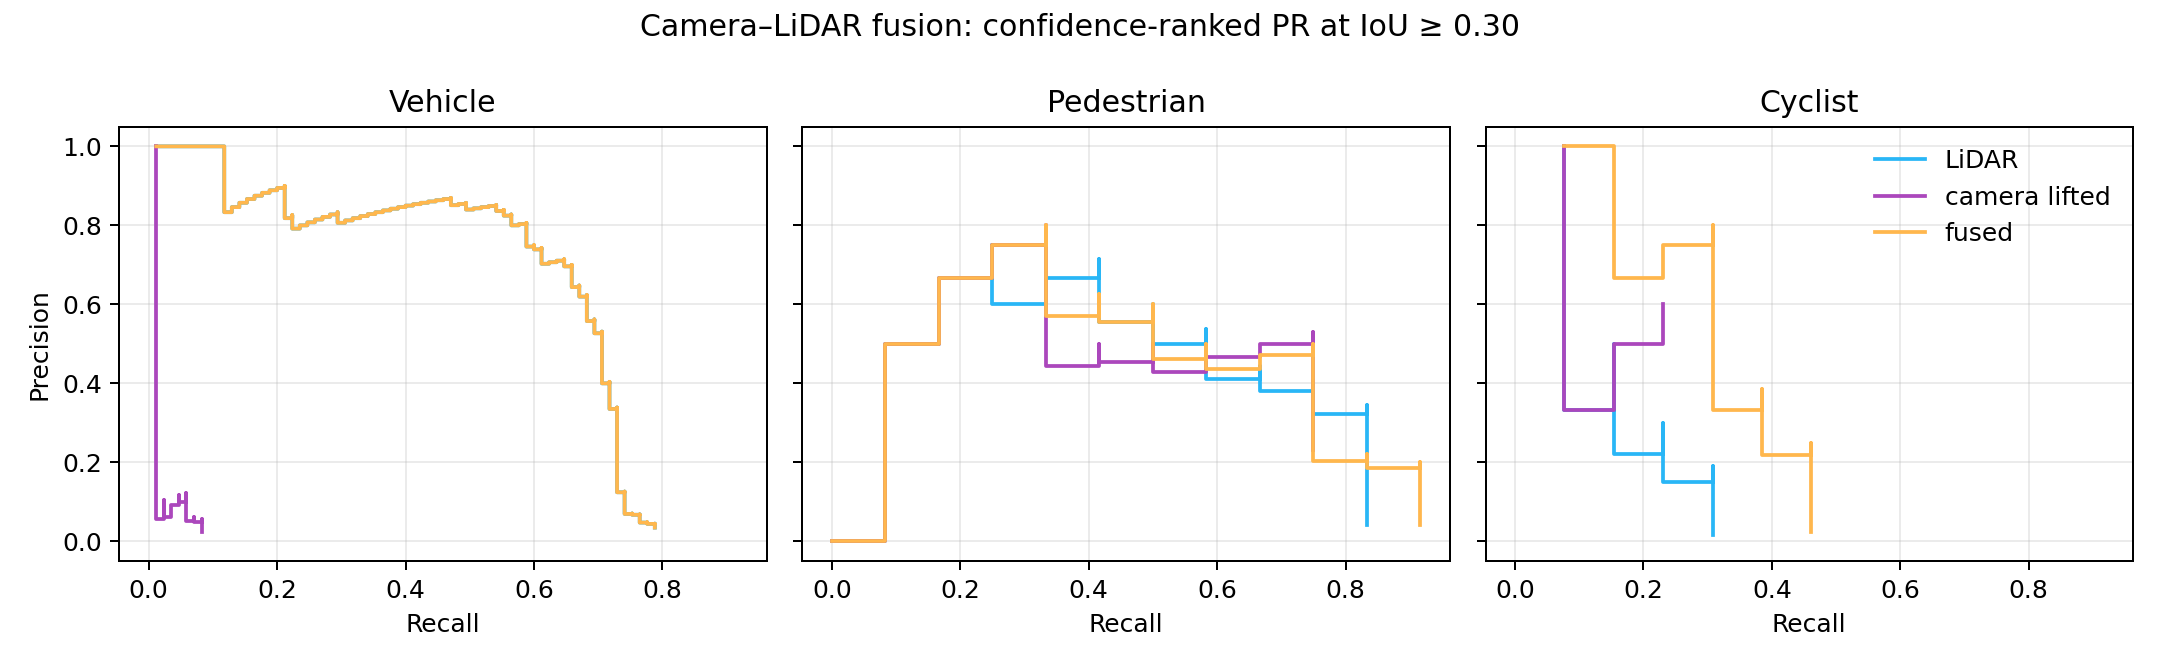

In [9]:
display(NotebookImage(filename=str(ROOT/'reports/figures/bev_v2_test_ap.png')))
display(NotebookImage(filename=str(ROOT/'reports/figures/bev_v2_pr_curves.png')))

## Reproduction and review checklist

1. Build private roles with `scripts/prepare_bev_roles.py`.
2. Cache one- and five-sweep inputs with `scripts/cache_bev_training_data.py`.
3. Train all three detectors with `scripts/train_bev_detectors.py`.
4. Freeze validation choices, then benchmark detectors and fusion on test.
5. Rebuild aggregate evidence and visuals with the two `build_bev_v2_*` scripts.
6. Test projection, fusion invariance, masked targets, rasterization, oriented
   IoU, AP, calibration, range slicing, and tracking.

Raw assets, IDs, caches, weights, and per-frame predictions remain private.